In [2]:
# Клонируем фоны с кегли
!pip install -q opendatasets lmdb fire natsort
import os
import opendatasets as od
# Скачиваем данные
od.download("https://www.kaggle.com/datasets/ziiiegen/backgrond-ocr-price")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.7 MB/s eta 0:00:00
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: ziiiegen
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/ziiiegen/backgrond-ocr-price


100%|██████████| 188k/188k [00:00<00:00, 59.3MB/s]

In [3]:
# Клонируем репозиторий TRDG
!git clone https://github.com/Belval/TextRecognitionDataGenerator.git

Cloning into 'TextRecognitionDataGenerator'...
remote: Enumerating objects: 1589, done.
remote: Total 1589 (delta 0), reused 0 (delta 0), pack-reused 1589 (from 1)
Receiving objects: 100% (1589/1589), 152.64 MiB | 12.39 MiB/s, done.
Resolving deltas: 100% (665/665), done.
Updating files: 100% (576/576), done.


In [4]:
!pip install arabic-reshaper
!pip install wikipedia
!pip install python-bidi

  Preparing metadata (setup.py) ... done
  Created wheel for wikipedia: filename=wikipedia-1.4.0-py3-none-any.whl size=11678 sha256=26578de264de939591d66404cd0ffbcb8472efbb8229fe3d400aece0be93bde2
  Stored in directory: /root/.cache/pip/wheels/63/47/7c/a9688349aa74d228ce0a9023229c6c0ac52ca2a40fe87679b8
Successfully built wikipedia
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 5.5 MB/s eta 0:00:00


In [5]:
import sys
sys.path.insert(0, '/content/TextRecognitionDataGenerator')

In [149]:
from trdg.generators.from_strings import GeneratorFromStrings

import matplotlib.pyplot as plt
import math
from PIL import Image, ImageDraw,  ImageFont, ImageFilter
import random
import numpy as np
from scipy.stats import lognorm
from tqdm import tqdm
import cv2

In [223]:
FONTS = [
    '/content/TT Commons Pro Trial ExtraBlack Italic.ttf',
    '/content/TT Commons Pro Trial ExtraBlack.ttf',
    '/content/TT Commons Pro Trial ExtraBold.ttf'
]
BACKGROUND_DIR = '/content/backgrond-ocr-price/background'

def get_char_count():
    """Получение количества символов через нормальное распределение"""
    val = np.random.normal(loc=2.53, scale=0.53)

    if val < 1.5: return 1
    elif 1.5 <= val < 2.5: return 2
    elif 2.5 <= val < 3.5: return 3
    elif 3.5 <= val < 5.0: return 4
    else: return 5

def generate_string(length):
    """Генерация строки из N случайных цифр"""
    digits = '0123456789'
    s = random.choice(digits[1:])
    for _ in range(length-1):
        s += random.choice(digits)
    return s

def fit_font_size(text, font_path, target_width, target_height,
                  max_width_ratio=0.8, max_height_ratio=0.7):
    size = 100
    font = ImageFont.truetype(font_path, size)
    while size > 8:
        bbox = font.getbbox(text)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]
        if text_w <= target_width * max_width_ratio and text_h <= target_height * max_height_ratio:
            break
        size -= 2
        font = ImageFont.truetype(font_path, size)
    return size

In [286]:
def apply_glare(img: Image.Image) -> Image.Image:
    """
    Накладывает блик: либо размытую белую полосу под углом,
    либо размытый белый прямоугольник случайного размера.
    alpha = 0.5 для естественной полупрозрачности.
    """
    img_array = np.array(img.convert('RGBA')).astype(np.float32)
    h, w = img_array.shape[:2]

    # Создаём маску блика
    glare_mask = np.zeros((h, w), dtype=np.float32)

    if random.random() < 0.5:
        # Вариант 1: белая полоса под углом через всё изображение
        angle = random.uniform(0, 180)  # случайный угол
        thickness = random.randint(1, 5)  # толщина полосы

        # Создаём временное чёрно-белое изображение для полосы
        temp = np.zeros((h, w), dtype=np.uint8)
        center_x, center_y = w // 2, h // 2
        length = int(np.sqrt(w**2 + h**2))  # диагональ — чтобы точно на всё изображение

        # Вычисляем конечные точки полосы
        rad = np.radians(angle)
        dx = length * np.cos(rad)
        dy = length * np.sin(rad)

        x1 = int(center_x - dx // 2)
        y1 = int(center_y - dy // 2)
        x2 = int(center_x + dx // 2)
        y2 = int(center_y + dy // 2)

        temp_pil = Image.fromarray(temp)
        draw = ImageDraw.Draw(temp_pil)
        draw.line([(x1, y1), (x2, y2)], fill=255, width=thickness)
        temp = np.array(temp_pil)

        # Размываем полосу
        temp_pil = Image.fromarray(temp)
        temp_pil = temp_pil.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 2)))
        glare_mask = np.array(temp_pil).astype(np.float32) / 255.0

    else:
        # Вариант 2: размытый белый квадратик/прямоугольник
        rect_w = random.randint(w // 4, w // 2)
        rect_h = random.randint(h // 6, h // 3)

        # Случайное положение
        x1 = random.randint(0, w - rect_w)
        y1 = random.randint(0, h - rect_h)
        x2 = x1 + rect_w
        y2 = y1 + rect_h

        # Рисуем прямоугольник
        temp = np.zeros((h, w), dtype=np.uint8)
        temp[y1:y2, x1:x2] = 255

        # Размываем
        temp_pil = Image.fromarray(temp)
        temp_pil = temp_pil.filter(ImageFilter.GaussianBlur(radius=random.uniform(0.2, 2)))
        glare_mask = np.array(temp_pil).astype(np.float32) / 255.0

    # Накладываем блик с альфа-каналом 0.5
    alpha = random.uniform(0.25, 0.9)
    glare_mask = glare_mask * alpha

    # Применяем маску: смешиваем белый с оригиналом
    white = np.ones_like(img_array) * 255
    white[:, :, 3] = 255  # непрозрачный белый

    # Интерполяция: результат = оригинал * (1 - маска) + белый * маска
    mask_3ch = np.stack([glare_mask] * 4, axis=-1)
    result = img_array * (1 - mask_3ch) + white * mask_3ch

    result = np.clip(result, 0, 255).astype(np.uint8)
    return Image.fromarray(result).convert('RGB')


def apply_linear_blur(img: Image.Image) -> Image.Image:
    """
    Лёгкий линейный смаз (motion blur) в случайном направлении.
    Использует OpenCV для фильтрации.
    """
    img_cv = np.array(img)

    # Длина смаза (небольшая, чтобы был лёгким)
    kernel_size = random.choice([1, 3])

    # Случайный угол направления смаза
    angle = random.uniform(0, 360)
    rad = np.radians(angle)

    # Создаём ядро motion blur
    kernel = np.zeros((kernel_size, kernel_size))

    # Вычисляем линию смаза
    center = kernel_size // 2
    dx = np.cos(rad)
    dy = np.sin(rad)

    # Заполняем линию в ядре
    if abs(dx) > abs(dy):
        # Преимущественно горизонтальное движение
        for i in range(kernel_size):
            x = i - center
            y = int(round(x * dy / dx)) if dx != 0 else 0
            if 0 <= y + center < kernel_size:
                kernel[y + center, i] = 1
    else:
        # Преимущественно вертикальное движение
        for i in range(kernel_size):
            y = i - center
            x = int(round(y * dx / dy)) if dy != 0 else 0
            if 0 <= x + center < kernel_size:
                kernel[i, x + center] = 1

    # Нормализация ядра
    kernel = kernel / kernel.sum()

    # Применяем фильтр
    result = cv2.filter2D(img_cv, -1, kernel)

    return Image.fromarray(result)


def apply_gaussian_blur(img: Image.Image) -> Image.Image:
    """
    Случайное небольшое гауссово размытие.
    """
    # Небольшой радиус, чтобы эффект был лёгким
    radius = random.uniform(0.2, 1.2)

    # Pillow принимает radius как float для GaussianBlur
    return img.filter(ImageFilter.GaussianBlur(radius=radius))

def apply_rotate(img: Image.Image) -> Image.Image:
    """
    Поворот через OpenCV с полноценным контролем над заполнением краёв.
    С шансом 50% — BORDER_REPLICATE (растягивание краевых пикселей, аналог BICUBIC-экстраполяции),
    с шансом 50% — заливка случайным цветом.
    """
    img_cv = np.array(img)
    h, w = img_cv.shape[:2]

    # Случайный угол
    alpha = random.uniform(-25, 25)

    # Матрица поворота
    center = (w // 2, h // 2)
    rotation_matrix = cv2.getRotationMatrix2D(center, alpha, 1.0)

    # Вычисляем новый размер холста (expand=True)
    cos = np.abs(rotation_matrix[0, 0])
    sin = np.abs(rotation_matrix[0, 1])
    new_w = int((h * sin) + (w * cos))
    new_h = int((h * cos) + (w * sin))

    # Корректируем матрицу под новый размер
    rotation_matrix[0, 2] += (new_w / 2) - center[0]
    rotation_matrix[1, 2] += (new_h / 2) - center[1]

    if random.random() < 0.9:
        # Вариант 1: BORDER_REPLICATE — растягивание краевых пикселей
        # Это близко к BICUBIC-интерполяции краёв
        border_mode = cv2.BORDER_REPLICATE
        border_value = None
    else:
        # Вариант 2: заливка случайным цветом
        border_mode = cv2.BORDER_CONSTANT
        border_value = (
            random.randint(0, 255),
            random.randint(0, 255),
            random.randint(0, 255)
        )

    # Применяем поворот
    rotated = cv2.warpAffine(
        img_cv,
        rotation_matrix,
        (new_w, new_h),
        flags=cv2.INTER_CUBIC,  # BICUBIC-интерполяция
        borderMode=border_mode,
        borderValue=border_value if border_value else (0, 0, 0)
    )

    return Image.fromarray(rotated)
def get_color():
        val = random.gauss(50, 5)
        return int(max(20, min(80, val)))

def get_black_color():
    r = get_color()
    g = get_color()
    b = get_color()

    return f'#{r:02X}{g:02X}{b:02X}'

In [289]:
images = []
labels = []
COUNT = 50000

for _ in tqdm(range(COUNT)):
    char_length = get_char_count()
    text = generate_string(char_length)

    width_float = lognorm.rvs(s=0.2400, loc=0.0, scale=32.7245, size=1)
    height_float = lognorm.rvs(s=0.2029, loc=0.0, scale=17.8612, size=1)

    target_width = np.clip(np.round(width_float).astype(int), a_min=15, a_max=None)[0]
    target_height = np.clip(np.round(height_float).astype(int), a_min=15, a_max=None)[0]

    SIZE = target_width + target_height

    while True:
        m_left = random.randint(7, 26)
        m_top = random.randint(1, 7)
        m_right = random.randint(1, 10)
        m_bot = random.randint(1, 7)
        if sum([m_left,m_top, m_right, m_bot]) <= 45:
            break

    generator = GeneratorFromStrings(
        [text],
        count=1,
        fonts=FONTS,
        size=SIZE,
        width=-1,
        skewing_angle=10,
        random_skew=True,
        background_type=3,
        image_dir = BACKGROUND_DIR,
        distorsion_type=random.choice([0, 1, 2]),
        distorsion_orientation=random.choice([0, 1, 2]),
        margins=(m_top, m_left, m_bot, m_right),
        character_spacing=random.choice([1, 2, 3]),
        text_color=get_black_color(),
        fit=False
    )

    for img, lbl in generator:
        # Масштаб
        width_ratio = target_width / img.width
        height_ratio = target_height / img.height
        ratio = np.mean([width_ratio, height_ratio])
        new_width = int(img.width * ratio)
        new_height = int(img.height * ratio)
        img_resized = img.resize((new_width, new_height), Image.Resampling.BICUBIC)

        # пост обработка
        flag_glare = random.random() < 0.25
        flag_rotate = random.random() < 0.1
        flag_linear_blurring = random.random() < 0.15
        flag_blur = random.random() < 0.25


        result = img_resized.copy()

        if flag_glare:
            result = apply_glare(result)

        if flag_linear_blurring:
            result = apply_linear_blur(result)

        if flag_blur:
            result = apply_gaussian_blur(result)

        if flag_rotate:
            result = apply_rotate(result)

        images.append(result)
        labels.append(lbl)

100%|██████████| 50000/50000 [04:31<00:00, 183.92it/s]


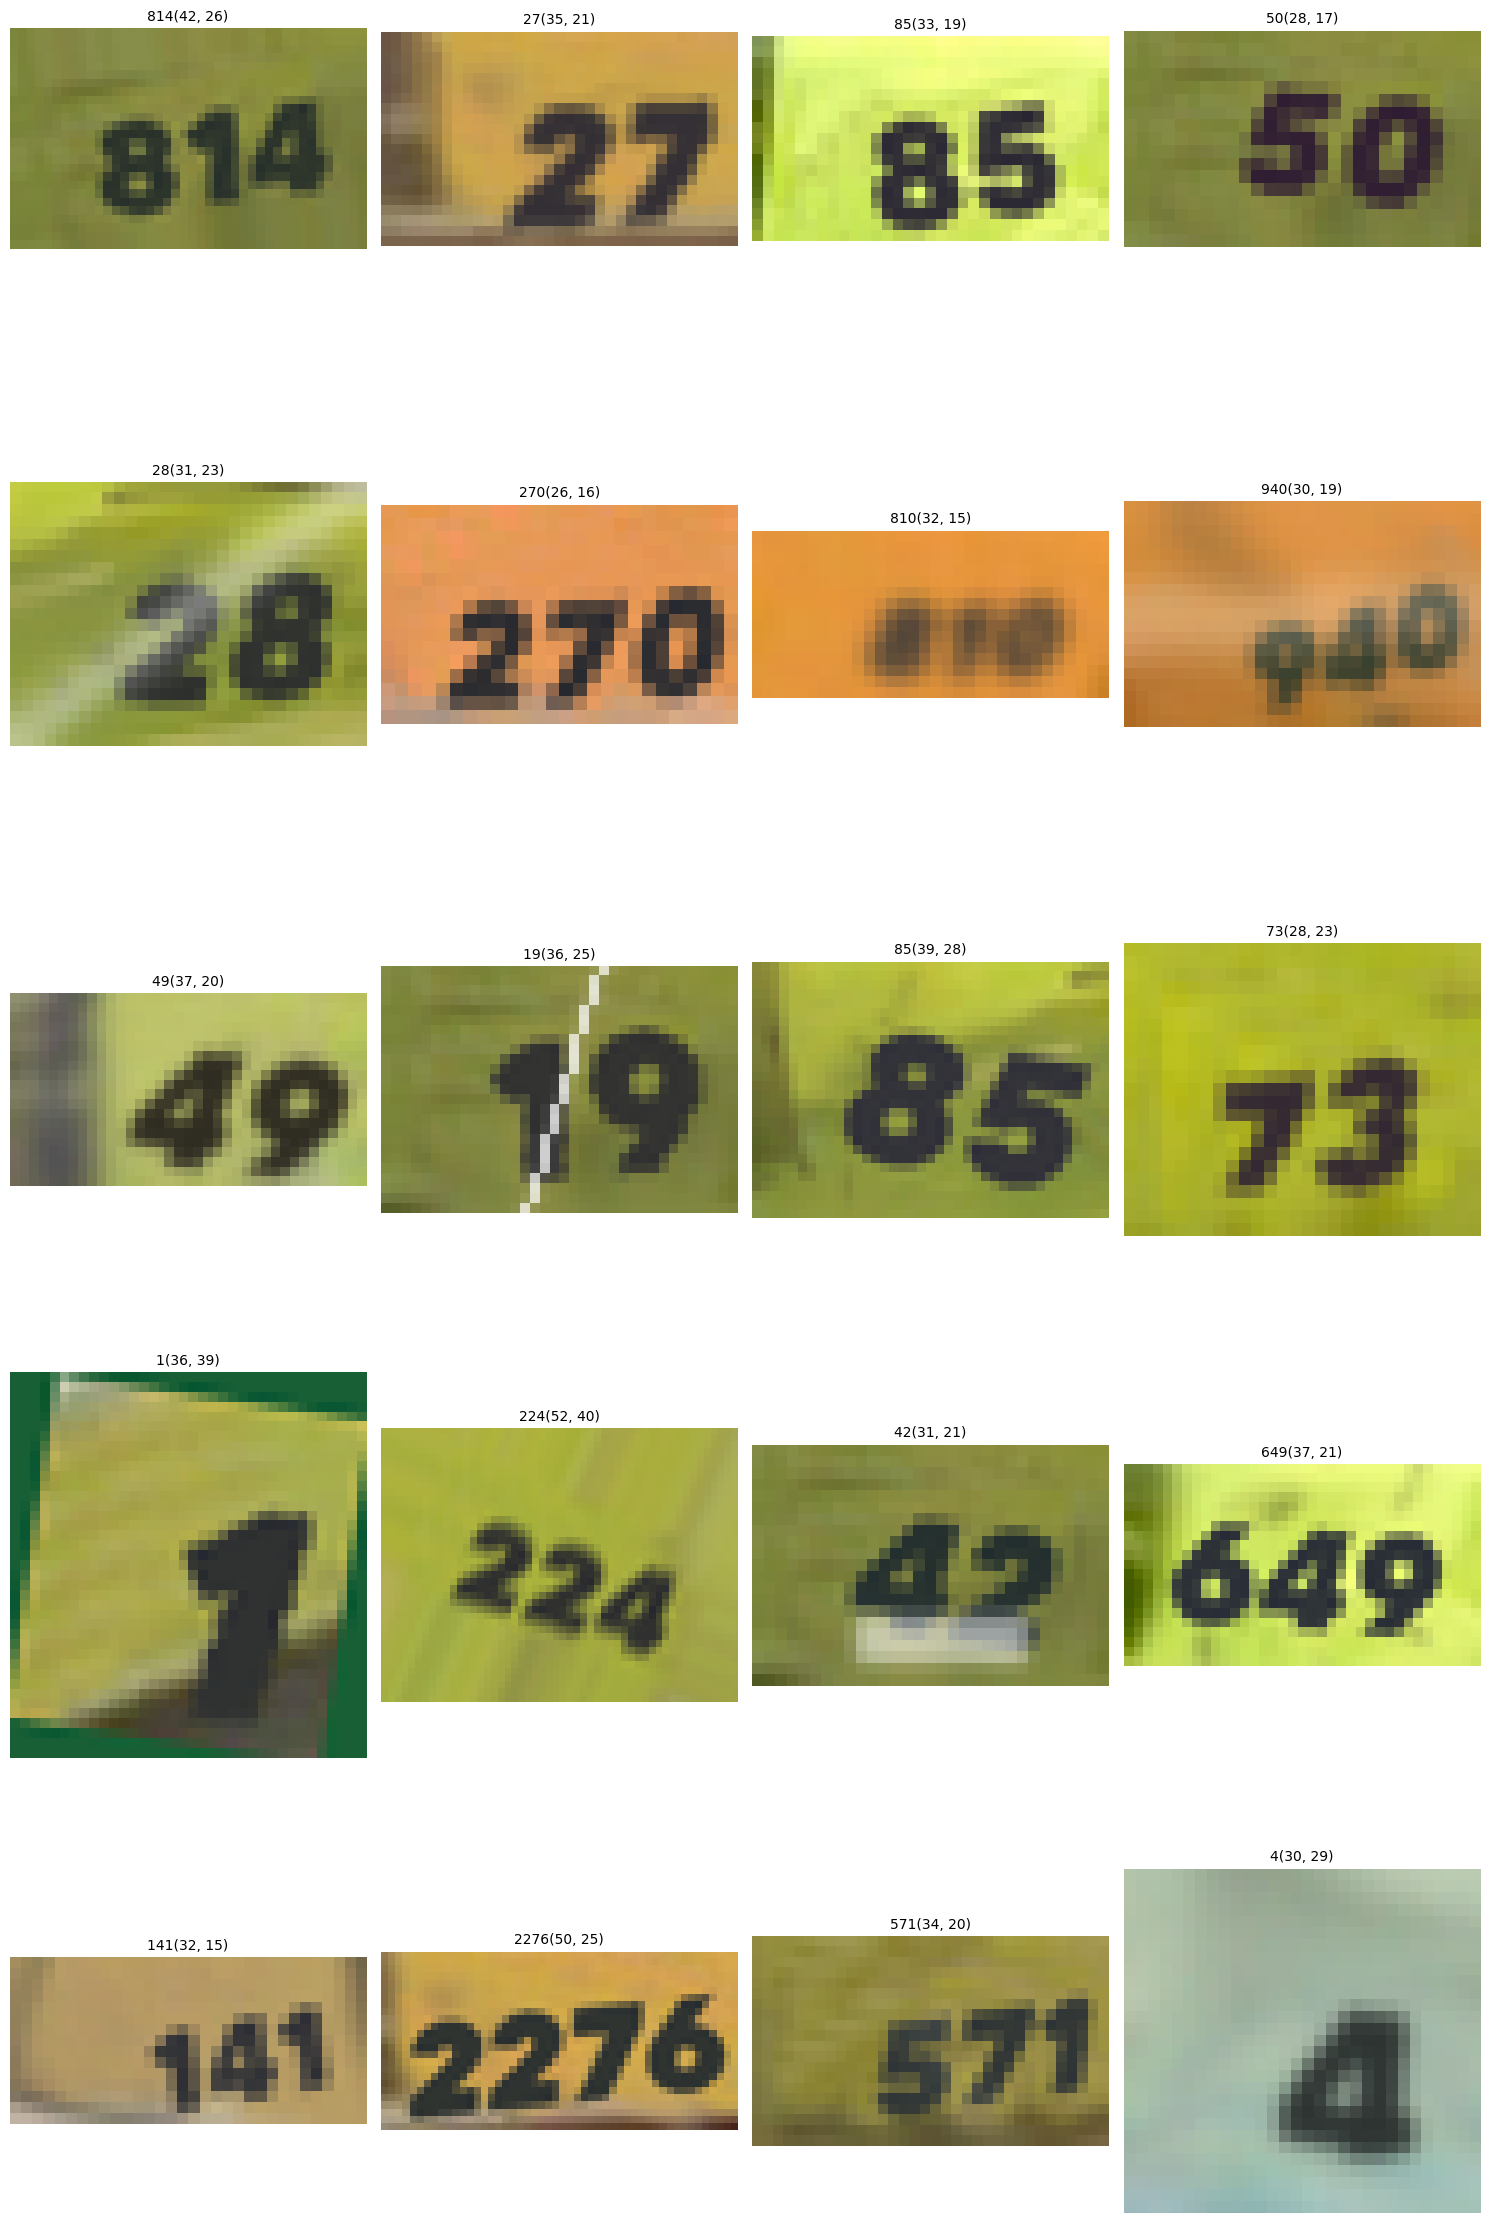

In [290]:
# Определяем размер сетки
n_images = 20
n_cols = 4  # количество столбцов
n_rows = math.ceil(n_images / n_cols)  # количество строк

# Создаем фигуру с сеткой
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # преобразуем в одномерный массив для удобства

# Отображаем каждое изображение
for idx, (img, lbl) in enumerate(zip(images, labels)):
    if idx == n_images:
        break
    axes[idx].imshow(img)
    axes[idx].set_title(str(lbl) + str(img.size), fontsize=10)
    axes[idx].axis('off')

# Скрываем лишние пустые подграфики
for idx in range(n_images, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [291]:
import os
import shutil
import pandas as pd
from google.colab import files


BASE_DIR = 'data_ideal_synthetics'
DATA_DIR = os.path.join(BASE_DIR, 'data')
CSV_PATH = os.path.join(BASE_DIR, 'labels.csv')
ZIP_NAME = 'data_ideal_synthetics'

if os.path.exists(BASE_DIR):
    shutil.rmtree(BASE_DIR)
os.makedirs(DATA_DIR)

csv_data = []

for i, (img, label) in enumerate(tqdm(zip(images, labels), total=len(images))):
    # Генерируем имя файла, например: 00001.jpg, 00002.jpg
    filename = f"ideal_synthetics_{i:05d}.jpg"
    filepath = os.path.join(DATA_DIR, filename)

    if img.mode != 'RGB':
        img = img.convert('RGB')

    img.save(filepath, format='JPEG', quality=95)

    csv_data.append({"Filename": filename, "Price": label})

print("Создание labels.csv...")
df = pd.DataFrame(csv_data)
df.to_csv(CSV_PATH, index=False)

# Шаг 4: Архивация
print(f"Архивация папки в {ZIP_NAME}.zip ... (Это займет около минуты)")
shutil.make_archive(ZIP_NAME, 'zip', BASE_DIR)

# Шаг 5: Скачивание на ваш ПК
print("Запуск скачивания...")
files.download(f"{ZIP_NAME}.zip")

100%|██████████| 50000/50000 [00:09<00:00, 5240.26it/s]


Создание labels.csv...
Архивация папки в data_ideal_synthetics.zip ... (Это займет около минуты)
Запуск скачивания...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>